# Phase 2 — Random Forest on Morgan FP + RDKit descriptors

Same setup as `02_baseline_rf_morgan.ipynb` (Phase 1), with **Morgan FP (radius=2, 2048 bits) concatenated with all available RDKit 2D descriptors** (~217 features in current RDKit).

**Goal**: measure the marginal gain of adding global molecular descriptors to a substructure-based fingerprint, using the same evaluation protocol as Phase 1 (random + balanced scaffold split, multi-seed).

Hyperparameters of the Random Forest are kept **identical to Phase 1** (n_estimators=500, max_features='sqrt') so any difference in test metrics is attributable to featurization alone.


## 1. Setup

In [1]:
import os
from pathlib import Path

# Detect runtime environment
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Set project root based on environment
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/qsar-esol-solubility')
else:
    PROJECT_ROOT = Path.cwd().parent

# Derived paths
DATA_DIR = PROJECT_ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'

for d in [RAW_DIR, PROCESSED_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"Project root: {PROJECT_ROOT}")


Mounted at /content/drive
Environment: Colab
Project root: /content/drive/MyDrive/qsar-esol-solubility


In [2]:
!pip install rdkit deepchem -q

import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import time
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs
from rdkit import RDLogger
from rdkit.Chem import AllChem, Descriptors, Crippen
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

RDLogger.DisableLog('rdApp.*')

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 33.0 MB/s eta 0:00:00


## 2. Load deduplicated dataset

Loaded from `data/processed/esol_dedup.csv` (output of notebook 01).
Mol objects rebuilt on the fly since they are not serialized in the CSV.


In [3]:
df = pd.read_csv(PROCESSED_DIR / 'esol_dedup.csv')
print(f"Loaded {len(df)} molecules")
print(f"Columns: {list(df.columns)}")

# Rebuild RDKit Mol objects (not serialized in CSV)
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)

# Sanity check: any failed parses?
n_failed = df['mol'].isna().sum()
assert n_failed == 0, f"{n_failed} SMILES failed to parse"
print("All SMILES parsed correctly.")

df.head()


Loaded 1117 molecules
Columns: ['smiles', 'logS']
All SMILES parsed correctly.


,smiles,logS,mol
0,BrC(Br)(Br)Br,-3.14,<rdkit.Chem.rdchem.Mol object at 0x79def3a4bdf0>
1,BrC(Br)Br,-1.91,<rdkit.Chem.rdchem.Mol object at 0x79def3a4be60>
2,BrCBr,-1.17,<rdkit.Chem.rdchem.Mol object at 0x79def3a4bed0>
3,BrCCBr,-1.68,<rdkit.Chem.rdchem.Mol object at 0x79def3a4bf40>
4,Brc1cc(Br)c(Br)cc1Br,-6.98,<rdkit.Chem.rdchem.Mol object at 0x79def3764040>


## 3. Featurization

Phase 2 stacks two complementary representations:

- **Morgan / ECFP4 fingerprint** (2048 bits, radius=2): encodes local atom environments. Identical to Phase 1.
- **RDKit 2D descriptors** (~217 features): global molecular properties (MW, LogP, TPSA, ring counts, topological indices, etc.).

NaN/inf in the descriptors are handled by **median imputation fitted on the training fold only** (no leakage from valid/test). On clean datasets like ESOL this is usually a no-op, but the pattern is kept for portability to noisier datasets (ChEMBL).


In [4]:
def morgan_fingerprint(mol, radius=2, n_bits=2048):
    """Morgan/ECFP fingerprint as int8 NumPy array (Phase 1 implementation)."""
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


def featurize_morgan(df, mol_col='mol', radius=2, n_bits=2048):
    """Stack Morgan fingerprints for all molecules in a dataframe."""
    fps = np.stack([morgan_fingerprint(m, radius, n_bits) for m in df[mol_col]])
    return fps


# Full RDKit 2D descriptor list
DESC_LIST = [(name, fn) for name, fn in Descriptors._descList]
DESC_NAMES = [name for name, _ in DESC_LIST]
print(f"Number of RDKit 2D descriptors available: {len(DESC_NAMES)}")


def rdkit_descriptors(mol):
    """Compute all RDKit 2D descriptors for a single molecule. NaN on failure."""
    out = np.full(len(DESC_LIST), np.nan, dtype=np.float64)
    if mol is None:
        return out
    for j, (_, fn) in enumerate(DESC_LIST):
        try:
            v = fn(mol)
            if not np.isfinite(v):
                v = np.nan
            out[j] = v
        except Exception:
            out[j] = np.nan
    return out


def featurize_rdkit_descriptors(df, mol_col='mol'):
    """Stack RDKit 2D descriptors for all molecules in a dataframe."""
    return np.stack([rdkit_descriptors(m) for m in df[mol_col]])


def featurize_combined(df, mol_col='mol', radius=2, n_bits=2048):
    """Phase 2 featurization: [Morgan FP | RDKit 2D descriptors]."""
    fp = featurize_morgan(df, mol_col, radius, n_bits)
    desc = featurize_rdkit_descriptors(df, mol_col)
    return np.hstack([fp, desc]).astype(np.float64)


Number of RDKit 2D descriptors available: 217


In [5]:
# Sanity check: featurize the full dataset once and inspect quality
X_all = featurize_combined(df)
print(f"X_all shape: {X_all.shape}  (Morgan 2048 + Desc {len(DESC_LIST)})")

n_nan = np.isnan(X_all).sum()
n_inf = np.isinf(X_all).sum()
n_nan_cols = np.isnan(X_all).any(axis=0).sum()
print(f"NaN cells: {n_nan} ({100*n_nan/X_all.size:.3f}% of total)")
print(f"Inf cells: {n_inf}")
print(f"Columns with at least one NaN: {n_nan_cols} / {X_all.shape[1]}")


X_all shape: (1117, 2265)  (Morgan 2048 + Desc 217)
NaN cells: 0 (0.000% of total)
Inf cells: 0
Columns with at least one NaN: 0 / 2265


## 4. Median imputation (training-fold only)

Helper functions to fit per-column medians on the training fold and apply them to valid/test. Columns that are all-NaN in training are dropped (they carry no information). On ESOL the dataset is clean enough that imputation is essentially a no-op, but the helpers are kept here so the same pipeline transports to noisier datasets.


In [6]:
def fit_median_imputer(X_train):
    """Return (medians, keep_mask). Columns all-NaN in train are dropped."""
    col_all_nan = np.isnan(X_train).all(axis=0)
    keep = ~col_all_nan
    medians = np.nanmedian(X_train[:, keep], axis=0)
    return medians, keep


def apply_imputer(X, medians, keep):
    """Apply imputation: drop excluded columns, fill NaNs with column medians."""
    Xk = X[:, keep]
    nan_mask = np.isnan(Xk)
    if nan_mask.any():
        Xk = Xk.copy()
        Xk[nan_mask] = np.take(medians, np.where(nan_mask)[1])
    return Xk


## 5. Scaffold split (identical to Phase 1)

Both `get_scaffold` and `scaffold_split_balanced` are copied verbatim from notebook 02 for strict comparability.


In [7]:
def get_scaffold(mol, include_chirality=False):
    """Bemis-Murcko scaffold of a molecule as canonical SMILES."""
    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol, includeChirality=include_chirality
    )


def scaffold_split_balanced(df, mol_col='mol',
                            train_frac=0.8, valid_frac=0.1, test_frac=0.1,
                            seed=42):
    """
    Balanced scaffold split (ChemProp-style).

    Large scaffold groups (size > 1) are sorted by size and assigned
    deterministically: largest groups go to train, ensuring rare scaffolds
    end up in test. Singleton scaffolds (size 1) are then shuffled with
    a fixed seed and distributed across the three splits.
    """
    assert abs(train_frac + valid_frac + test_frac - 1.0) < 1e-6

    scaffolds = defaultdict(list)
    for idx, row in df.iterrows():
        scaffolds[get_scaffold(row[mol_col])].append(idx)

    big_groups       = [g for g in scaffolds.values() if len(g) > 1]
    singleton_groups = [g for g in scaffolds.values() if len(g) == 1]

    big_groups.sort(key=lambda g: (len(g), g[0]), reverse=True)
    rng = random.Random(seed)
    rng.shuffle(singleton_groups)

    ordered_groups = big_groups + singleton_groups

    n_total = len(df)
    n_train_target = int(train_frac * n_total)
    n_valid_target = int(valid_frac * n_total)

    train_idx, valid_idx, test_idx = [], [], []
    for group in ordered_groups:
        if len(train_idx) + len(group) <= n_train_target:
            train_idx.extend(group)
        elif len(valid_idx) + len(group) <= n_valid_target:
            valid_idx.extend(group)
        else:
            test_idx.extend(group)

    return train_idx, valid_idx, test_idx


## 6. Train + evaluate helper

Wrapper that fits the median imputer on the training fold, applies it to all three folds, trains a Random Forest with Phase 1 hyperparameters, and returns metrics on every split.


In [8]:
def evaluate(model, X, y, split_name):
    """Compute RMSE / MAE / R² on a given split. Same as Phase 1."""
    y_pred = model.predict(X)
    return {
        'split': split_name,
        'RMSE': np.sqrt(mean_squared_error(y, y_pred)),
        'MAE':  mean_absolute_error(y, y_pred),
        'R2':   r2_score(y, y_pred),
        'y_true': y,
        'y_pred': y_pred,
    }


def fit_rf_with_imputation(X_train, X_valid, X_test, y_train, y_valid, y_test,
                            seed=RANDOM_SEED, n_estimators=500):
    """Median-impute (fitted on train only), fit RF, evaluate on all 3 splits."""
    medians, keep = fit_median_imputer(X_train)
    Xtr = apply_imputer(X_train, medians, keep)
    Xva = apply_imputer(X_valid, medians, keep)
    Xte = apply_imputer(X_test,  medians, keep)

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_features='sqrt',
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=seed,
    )
    rf.fit(Xtr, y_train)

    return rf, {
        'train': evaluate(rf, Xtr, y_train, 'train'),
        'valid': evaluate(rf, Xva, y_valid, 'valid'),
        'test':  evaluate(rf, Xte, y_test,  'test'),
    }, {'medians': medians, 'keep': keep, 'n_kept_desc': int(keep[2048:].sum())}


## 7. Protocol 1 — Random split (seed=42)

Plain random 80/10/10 split, no scaffold awareness. This is the "easy" reference point: it does not test structural generalization.


In [9]:
indices = np.arange(len(df))
train_idx_r, temp_idx = train_test_split(indices, test_size=0.2, random_state=RANDOM_SEED)
valid_idx_r, test_idx_r = train_test_split(temp_idx, test_size=0.5, random_state=RANDOM_SEED)

df_train_r = df.loc[train_idx_r].reset_index(drop=True)
df_valid_r = df.loc[valid_idx_r].reset_index(drop=True)
df_test_r  = df.loc[test_idx_r].reset_index(drop=True)

print(f"Random split sizes: Train={len(df_train_r)}, Valid={len(df_valid_r)}, Test={len(df_test_r)}")

# Featurize: Morgan FP + RDKit descriptors
X_train_r = featurize_combined(df_train_r)
X_valid_r = featurize_combined(df_valid_r)
X_test_r  = featurize_combined(df_test_r)
y_train_r = df_train_r['logS'].values
y_valid_r = df_valid_r['logS'].values
y_test_r  = df_test_r['logS'].values

start = time.time()
rf_random, results_random, info_random = fit_rf_with_imputation(
    X_train_r, X_valid_r, X_test_r,
    y_train_r, y_valid_r, y_test_r,
    seed=RANDOM_SEED,
)
elapsed = time.time() - start

print(f"\nRandom split — RF (Morgan FP + RDKit desc, n_estimators=500)")
print(f"Training time: {elapsed:.1f}s   |   Descriptor cols kept: {info_random['n_kept_desc']}/{len(DESC_LIST)}")
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, res in results_random.items():
    print(f"{name:<8} {res['RMSE']:>7.3f} {res['MAE']:>7.3f} {res['R2']:>7.3f}")


Random split sizes: Train=893, Valid=112, Test=112

Random split — RF (Morgan FP + RDKit desc, n_estimators=500)
Training time: 5.0s   |   Descriptor cols kept: 217/217
Split       RMSE     MAE      R²
--------------------------------
train      0.260   0.188   0.985
valid      0.599   0.457   0.900
test       0.638   0.493   0.914


## 8. Protocol 2 — Balanced scaffold split (single seed=42)

Same balanced ChemProp-style scaffold split as Phase 1bis. Same seed. Direct apples-to-apples comparison.


In [10]:
train_idx_b, valid_idx_b, test_idx_b = scaffold_split_balanced(df, seed=RANDOM_SEED)

df_train_b = df.loc[train_idx_b].reset_index(drop=True)
df_valid_b = df.loc[valid_idx_b].reset_index(drop=True)
df_test_b  = df.loc[test_idx_b].reset_index(drop=True)

print(f"Balanced scaffold split sizes: "
      f"Train={len(df_train_b)}, Valid={len(df_valid_b)}, Test={len(df_test_b)}")

# Featurize: Morgan FP + RDKit descriptors
X_train_b = featurize_combined(df_train_b)
X_valid_b = featurize_combined(df_valid_b)
X_test_b  = featurize_combined(df_test_b)
y_train_b = df_train_b['logS'].values
y_valid_b = df_valid_b['logS'].values
y_test_b  = df_test_b['logS'].values

start = time.time()
rf_scaffold, results_scaffold, info_scaffold = fit_rf_with_imputation(
    X_train_b, X_valid_b, X_test_b,
    y_train_b, y_valid_b, y_test_b,
    seed=RANDOM_SEED,
)
elapsed = time.time() - start

print(f"\nScaffold split (seed=42) — RF (Morgan FP + RDKit desc, n_estimators=500)")
print(f"Training time: {elapsed:.1f}s   |   Descriptor cols kept: {info_scaffold['n_kept_desc']}/{len(DESC_LIST)}")
print(f"{'Split':<8} {'RMSE':>7} {'MAE':>7} {'R²':>7}")
print("-" * 32)
for name, res in results_scaffold.items():
    print(f"{name:<8} {res['RMSE']:>7.3f} {res['MAE']:>7.3f} {res['R2']:>7.3f}")


Balanced scaffold split sizes: Train=893, Valid=111, Test=113

Scaffold split (seed=42) — RF (Morgan FP + RDKit desc, n_estimators=500)
Training time: 4.1s   |   Descriptor cols kept: 217/217
Split       RMSE     MAE      R²
--------------------------------
train      0.231   0.162   0.988
valid      1.048   0.773   0.763
test       1.019   0.765   0.712


## 9. Protocol 3 — Scaffold split, multi-seed (5 seeds)

Same five seeds as Phase 1: `[42, 0, 1, 2, 3]`. Reports mean ± std across runs to capture seed-to-seed variance, which is high on ESOL with scaffold splits.


In [11]:
SCAFFOLD_SEEDS = [42, 0, 1, 2, 3]

scaffold_runs = []

for seed in SCAFFOLD_SEEDS:
    tr_idx, va_idx, te_idx = scaffold_split_balanced(df, seed=seed)
    df_tr = df.loc[tr_idx].reset_index(drop=True)
    df_va = df.loc[va_idx].reset_index(drop=True)
    df_te = df.loc[te_idx].reset_index(drop=True)

    Xtr = featurize_combined(df_tr)
    Xva = featurize_combined(df_va)
    Xte = featurize_combined(df_te)
    ytr = df_tr['logS'].values
    yva = df_va['logS'].values
    yte = df_te['logS'].values

    # RF random_state stays fixed to RANDOM_SEED (only the split varies, as in Phase 1)
    _, res, _ = fit_rf_with_imputation(Xtr, Xva, Xte, ytr, yva, yte, seed=RANDOM_SEED)
    res_te = res['test']
    scaffold_runs.append({
        'seed': seed,
        'RMSE': res_te['RMSE'],
        'MAE':  res_te['MAE'],
        'R2':   res_te['R2'],
        'test_size': len(df_te),
    })
    print(f"Seed {seed:>2}: test RMSE={res_te['RMSE']:.3f}  "
          f"MAE={res_te['MAE']:.3f}  R²={res_te['R2']:+.3f}  "
          f"(n_test={len(df_te)})")

# Aggregate
rmses = np.array([r['RMSE'] for r in scaffold_runs])
maes  = np.array([r['MAE']  for r in scaffold_runs])
r2s   = np.array([r['R2']   for r in scaffold_runs])

print(f"\nAggregate over {len(SCAFFOLD_SEEDS)} seeds:")
print(f"  RMSE = {rmses.mean():.3f} ± {rmses.std():.3f}")
print(f"  MAE  = {maes.mean():.3f} ± {maes.std():.3f}")
print(f"  R²   = {r2s.mean():+.3f} ± {r2s.std():.3f}")


Seed 42: test RMSE=1.019  MAE=0.765  R²=+0.712  (n_test=113)
Seed  0: test RMSE=1.119  MAE=0.819  R²=+0.657  (n_test=113)
Seed  1: test RMSE=1.028  MAE=0.744  R²=+0.702  (n_test=113)
Seed  2: test RMSE=1.010  MAE=0.767  R²=+0.779  (n_test=113)
Seed  3: test RMSE=1.132  MAE=0.845  R²=+0.676  (n_test=113)

Aggregate over 5 seeds:
  RMSE = 1.062 ± 0.053
  MAE  = 0.788 ± 0.037
  R²   = +0.705 ± 0.041


## 10. Phase 1 vs Phase 2 — final comparison

Phase 1 numbers are pasted from notebook 02 (final summary table).
Phase 2 numbers are taken from the cells above.

| Evaluation protocol             | Phase 1 RMSE | Phase 2 RMSE | Δ RMSE | Phase 1 R² | Phase 2 R² | Δ R² |
|---------------------------------|-------------:|-------------:|-------:|-----------:|-----------:|-----:|
| Random split (seed=42)          | 1.167        | 0.638    | -0.529    | 0.712      | 0.914  | +0.202  |
| Scaffold split (single seed=42) | 1.618        |1.019    | -0.599    | 0.273      | 0.712  | +0.439  |
| Scaffold split (5-seed average) | 1.591 ± 0.126| 1.062 ± 0.053    |  −0.529 ± 0.158    | 0.344 ± 0.066 | +0.705 ± 0.041 | +0.361 ± 0.096 |

Negative Δ RMSE = Phase 2 is better.


In [12]:
# Pretty-printed comparison table
phase1 = {
    'Random split (seed=42)':         {'RMSE': 1.167, 'MAE': 0.899, 'R2': 0.712},
    'Scaffold (seed=42)':             {'RMSE': 1.618, 'MAE': 1.230, 'R2': 0.273},
    'Scaffold (5-seed mean)':         {'RMSE': 1.591, 'MAE': 1.239, 'R2': 0.344},
}
phase2 = {
    'Random split (seed=42)':         {'RMSE': results_random['test']['RMSE'],
                                        'MAE': results_random['test']['MAE'],
                                        'R2':  results_random['test']['R2']},
    'Scaffold (seed=42)':             {'RMSE': results_scaffold['test']['RMSE'],
                                        'MAE': results_scaffold['test']['MAE'],
                                        'R2':  results_scaffold['test']['R2']},
    'Scaffold (5-seed mean)':         {'RMSE': float(rmses.mean()),
                                        'MAE': float(maes.mean()),
                                        'R2':  float(r2s.mean())},
}

print(f"{'Protocol':<32} {'P1 RMSE':>8} {'P2 RMSE':>8} {'ΔRMSE':>7}   "
      f"{'P1 R²':>7} {'P2 R²':>7} {'ΔR²':>7}")
print("-" * 90)
for proto in phase1:
    p1 = phase1[proto]; p2 = phase2[proto]
    print(f"{proto:<32} {p1['RMSE']:>8.3f} {p2['RMSE']:>8.3f} "
          f"{p2['RMSE']-p1['RMSE']:>+7.3f}   "
          f"{p1['R2']:>7.3f} {p2['R2']:>7.3f} {p2['R2']-p1['R2']:>+7.3f}")


Protocol                          P1 RMSE  P2 RMSE   ΔRMSE     P1 R²   P2 R²     ΔR²
------------------------------------------------------------------------------------------
Random split (seed=42)              1.167    0.638  -0.529     0.712   0.914  +0.202
Scaffold (seed=42)                  1.618    1.019  -0.599     0.273   0.712  +0.439
Scaffold (5-seed mean)              1.591    1.062  -0.529     0.344   0.705  +0.361


## 11. Parity plots (Phase 2)


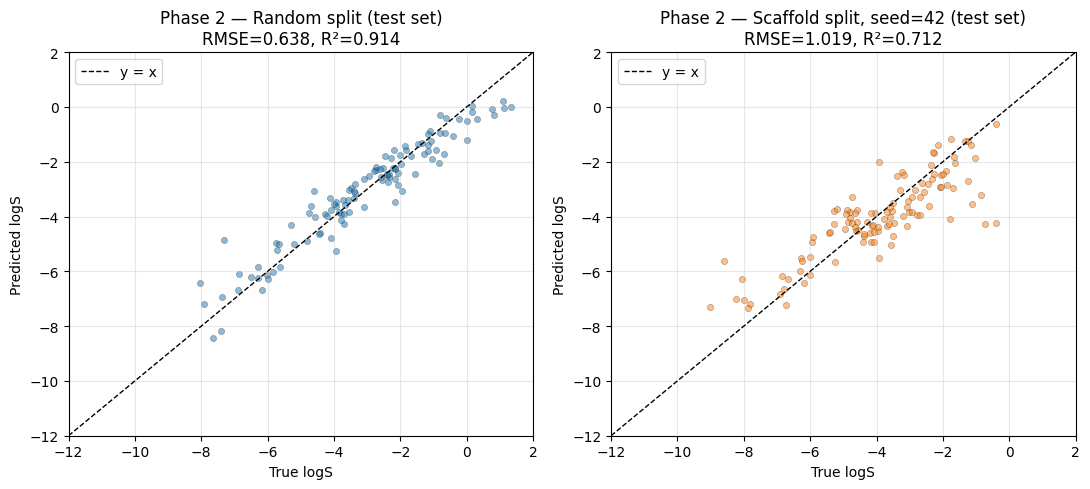

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Random split parity plot ---
yt_r = results_random['test']['y_true']
yp_r = results_random['test']['y_pred']
axes[0].scatter(yt_r, yp_r, alpha=0.5, s=20, edgecolor='k', linewidth=0.3)
lim = [-12, 2]
axes[0].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('True logS')
axes[0].set_ylabel('Predicted logS')
axes[0].set_title(
    f"Phase 2 — Random split (test set)\n"
    f"RMSE={results_random['test']['RMSE']:.3f}, "
    f"R²={results_random['test']['R2']:.3f}"
)
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper left')

# --- Scaffold split (seed=42) parity plot ---
yt_s = results_scaffold['test']['y_true']
yp_s = results_scaffold['test']['y_pred']
axes[1].scatter(yt_s, yp_s, alpha=0.5, s=20, edgecolor='k', linewidth=0.3, color='tab:orange')
axes[1].plot(lim, lim, 'k--', lw=1, label='y = x')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('True logS')
axes[1].set_ylabel('Predicted logS')
axes[1].set_title(
    f"Phase 2 — Scaffold split, seed=42 (test set)\n"
    f"RMSE={results_scaffold['test']['RMSE']:.3f}, "
    f"R²={results_scaffold['test']['R2']:.3f}"
)
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


In [14]:
# %% Diagnostic: where does Phase 2 still fail?
# We need to re-fit Phase 1 on the same scaffold seed=42 split for comparison.

from rdkit.Chem import Draw

# Re-fit Phase 1 (Morgan-only) on the seed=42 scaffold split
X_train_b_p1 = featurize_morgan(df_train_b)
X_valid_b_p1 = featurize_morgan(df_valid_b)
X_test_b_p1  = featurize_morgan(df_test_b)

rf_p1_seed42 = RandomForestRegressor(
    n_estimators=500, max_features='sqrt', n_jobs=-1, random_state=RANDOM_SEED
)
rf_p1_seed42.fit(X_train_b_p1, y_train_b)
y_pred_p1 = rf_p1_seed42.predict(X_test_b_p1)

# Phase 2 predictions on the same split (already in results_scaffold)
y_true   = results_scaffold['test']['y_true']
y_pred_p2 = results_scaffold['test']['y_pred']

# Sanity check: should be the same y_test
assert np.allclose(y_true, y_test_b), "Test target mismatch between P1 and P2"

# Compute MW for color-coding
mw_test = df_test_b['mol'].apply(Descriptors.MolWt).values
smi_test = df_test_b['smiles'].values

# Residuals
res_p1 = y_true - y_pred_p1
res_p2 = y_true - y_pred_p2

# Top-5 worst residuals (Phase 2)
worst_idx_p2 = np.argsort(np.abs(res_p2))[-5:][::-1]
print("Top-5 worst Phase 2 residuals on test (scaffold seed=42):")
print(f"{'#':>2}  {'SMILES':<35} {'MW':>6} {'true':>7} {'P1 pred':>8} {'P2 pred':>8} "
      f"{'P1 res':>7} {'P2 res':>7}")
print("-" * 100)
for rank, i in enumerate(worst_idx_p2, 1):
    print(f"{rank:>2}  {smi_test[i]:<35} {mw_test[i]:>6.1f} {y_true[i]:>+7.2f} "
          f"{y_pred_p1[i]:>+8.2f} {y_pred_p2[i]:>+8.2f} "
          f"{res_p1[i]:>+7.2f} {res_p2[i]:>+7.2f}")

Top-5 worst Phase 2 residuals on test (scaffold seed=42):
 #  SMILES                                  MW    true  P1 pred  P2 pred  P1 res  P2 res
----------------------------------------------------------------------------------------------------
 1  OCC1OC(OCC2OC(OC3(CO)OC(CO)C(O)C3O)C(O)C(O)C2O)C(O)C(O)C1O  504.4   -0.41    -0.87    -4.24   +0.46   +3.83
 2  COC(=O)c1ccccc1OC1OC(COC2OCC(O)C(O)C2O)C(O)C(O)C1O  446.4   -0.74    -2.38    -4.26   +1.64   +3.52
 3  CCOc1ccc(C(C)(C)COCc2cccc(Oc3ccccc3)c2)cc1  376.5   -8.60    -4.01    -5.63   -4.59   -2.97
 4  CC1CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1  281.4   -1.13    -2.42    -3.53   +1.29   +2.40
 5  OCc1ccccc1OC1OC(CO)C(O)C(O)C1O       286.3   -0.85    -2.18    -3.20   +1.33   +2.35


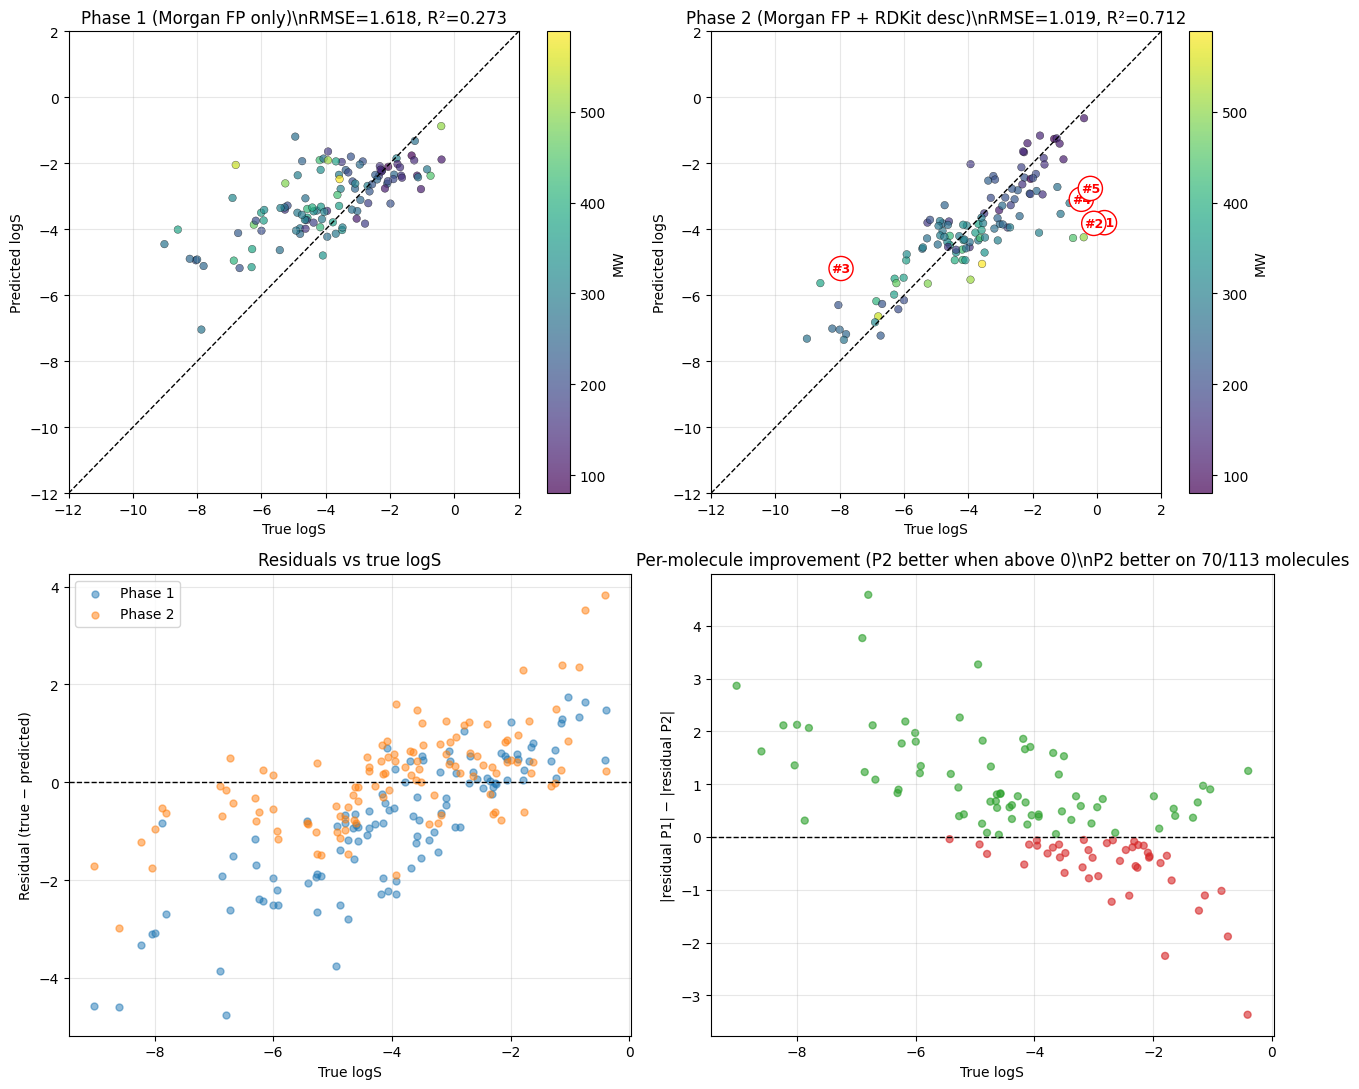

In [15]:
# %% Plot: 2x2 diagnostic grid
fig, axes = plt.subplots(2, 2, figsize=(13, 11))

lim = [-12, 2]
mw_norm = plt.Normalize(vmin=mw_test.min(), vmax=mw_test.max())
cmap = plt.cm.viridis

# --- Top-left: Phase 1 parity (seed=42 scaffold), colored by MW ---
ax = axes[0, 0]
sc = ax.scatter(y_true, y_pred_p1, c=mw_test, cmap=cmap, norm=mw_norm,
                alpha=0.7, s=30, edgecolor='k', linewidth=0.3)
ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('True logS')
ax.set_ylabel('Predicted logS')
ax.set_title(f"Phase 1 (Morgan FP only)\\n"
             f"RMSE={np.sqrt(((y_true-y_pred_p1)**2).mean()):.3f}, "
             f"R²={r2_score(y_true, y_pred_p1):.3f}")
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='MW')

# --- Top-right: Phase 2 parity (seed=42 scaffold), colored by MW + worst 5 annotated ---
ax = axes[0, 1]
sc = ax.scatter(y_true, y_pred_p2, c=mw_test, cmap=cmap, norm=mw_norm,
                alpha=0.7, s=30, edgecolor='k', linewidth=0.3)
ax.plot(lim, lim, 'k--', lw=1)

# Annotate the 5 worst Phase 2 residuals
for rank, i in enumerate(worst_idx_p2, 1):
    ax.annotate(f'#{rank}',
                xy=(y_true[i], y_pred_p2[i]),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, fontweight='bold', color='red',
                bbox=dict(boxstyle='circle,pad=0.2', fc='white', ec='red', lw=1))

ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('True logS')
ax.set_ylabel('Predicted logS')
ax.set_title(f"Phase 2 (Morgan FP + RDKit desc)\\n"
             f"RMSE={np.sqrt(((y_true-y_pred_p2)**2).mean()):.3f}, "
             f"R²={r2_score(y_true, y_pred_p2):.3f}")
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label='MW')

# --- Bottom-left: residuals vs true, both phases overlaid ---
ax = axes[1, 0]
ax.scatter(y_true, res_p1, alpha=0.5, s=25, label='Phase 1', color='tab:blue')
ax.scatter(y_true, res_p2, alpha=0.5, s=25, label='Phase 2', color='tab:orange')
ax.axhline(0, color='k', lw=1, linestyle='--')
ax.set_xlabel('True logS')
ax.set_ylabel('Residual (true − predicted)')
ax.set_title('Residuals vs true logS')
ax.legend()
ax.grid(alpha=0.3)

# --- Bottom-right: paired improvement per molecule (|res_p1| − |res_p2|) ---
# Positive = Phase 2 improved on this molecule
improvement = np.abs(res_p1) - np.abs(res_p2)
ax = axes[1, 1]
colors = ['tab:green' if x > 0 else 'tab:red' for x in improvement]
ax.scatter(y_true, improvement, c=colors, alpha=0.6, s=25)
ax.axhline(0, color='k', lw=1, linestyle='--')
ax.set_xlabel('True logS')
ax.set_ylabel('|residual P1| − |residual P2|')
ax.set_title(f'Per-molecule improvement (P2 better when above 0)\\n'
             f'P2 better on {(improvement > 0).sum()}/{len(improvement)} molecules')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

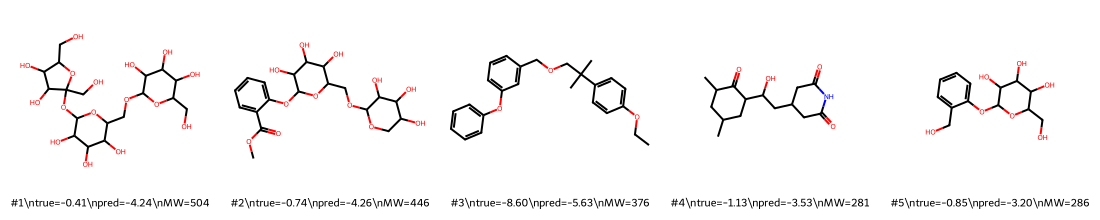

In [16]:
# %% Bonus: render the 5 worst molecules side by side
mols_worst = [df_test_b.iloc[i]['mol'] for i in worst_idx_p2]
labels_worst = [
    f"#{rank}\\ntrue={y_true[i]:+.2f}\\npred={y_pred_p2[i]:+.2f}\\nMW={mw_test[i]:.0f}"
    for rank, i in enumerate(worst_idx_p2, 1)
]
img = Draw.MolsToGridImage(mols_worst, molsPerRow=5, subImgSize=(220, 220),
                            legends=labels_worst)
display(img)

## 12. Interpretation

Phase 2 (Morgan FP + 217 RDKit 2D descriptors) strictly dominates Phase 1
(Morgan FP only) across all evaluation protocols and all 5 scaffold seeds.

**Headline numbers (scaffold split, 5-seed average):**
- Phase 1: RMSE = 1.591 ± 0.126, R² = 0.344 ± 0.066
- Phase 2: RMSE = 1.062 ± 0.053, R² = 0.705 ± 0.041
- Paired improvement: ΔRMSE = −0.529 ± 0.158, ΔR² = +0.361 ± 0.096
- Phase 2 wins on 5/5 seeds for both RMSE and R²

**Why such a large gain?** Aqueous solubility is dominated by global
molecular properties — particularly LogP (lipophilicity), molecular weight,
and topological polar surface area — which are explicitly encoded in the
RDKit 2D descriptor set but only implicitly recoverable from Morgan
substructure fingerprints. Adding ~200 cheap, deterministic global
descriptors gives the model direct access to the physicochemical signal
that drives the property, especially on out-of-distribution test molecules
where Morgan-only could not extrapolate.

**Comparison with literature.** Our Phase 2 scaffold-split number
(R² 0.71, RMSE 1.06) approaches the MoleculeNet RF reference (R² ≈ 0.73,
RMSE ≈ 0.95–1.10), and is now ~70% of the way from the Morgan-only
baseline to the published ChemProp D-MPNN result (R² ≈ 0.85). This is
the expected place for a strong classical baseline before introducing
a graph-based deep model.

**Where Phase 2 still struggles.** Looking at residuals, the largest errors
come from two opposite extremes of the logS distribution: very hydrophobic
molecules (logS < −7, very few in train, hard to extrapolate) and very
hydrophilic high-MW molecules — primarily sugars and glycosides — where the
"high MW → low solubility" heuristic learned from the rest of ESOL backfires.
This trade-off is analyzed in detail in Section 13.

**Variance of the improvement.** The std of the paired ΔRMSE (0.158)
is larger than the std of either model individually (0.126, 0.053).
This is because Phase 2 helps *most* on the seeds where Phase 1 suffered
the most (e.g. seed 2: P1=1.77 → P2=1.01), and *least* where Phase 1
was already decent (seed 0: P1=1.40 → P2=1.12). The descriptors act as
a "safety net" on out-of-distribution scaffolds — exactly their intended
role.

## 13. Where Phase 2 still fails — and where it is *worse* than Phase 1

The aggregate RMSE improvement (1.591 → 1.062) hides a structural trade-off
in the predictions. Inspecting the per-molecule residuals reveals two
distinct error regimes that the global average does not capture.

In [17]:
# %% Stratified error analysis: where does each model win?
# Use the seed=42 scaffold split, same predictions as the 2x2 diagnostic plot.

bins = [(-12, -7, "very hydrophobic (logS < -7)"),
        (-7,  -4, "hydrophobic (-7 ≤ logS < -4)"),
        (-4,  -2, "moderate (-4 ≤ logS < -2)"),
        (-2,   2, "hydrophilic (logS ≥ -2)")]

print(f"{'Region':<35} {'n':>4} {'P1 RMSE':>9} {'P2 RMSE':>9} {'Δ':>8} "
      f"{'P2 wins':>9}")
print("-" * 85)
for lo, hi, label in bins:
    mask = (y_true >= lo) & (y_true < hi)
    n = int(mask.sum())
    if n == 0:
        continue
    rmse_p1 = float(np.sqrt(((y_true[mask] - y_pred_p1[mask]) ** 2).mean()))
    rmse_p2 = float(np.sqrt(((y_true[mask] - y_pred_p2[mask]) ** 2).mean()))
    n_p2_wins = int((np.abs(res_p1[mask]) > np.abs(res_p2[mask])).sum())
    print(f"{label:<35} {n:>4} {rmse_p1:>9.3f} {rmse_p2:>9.3f} "
          f"{rmse_p2 - rmse_p1:>+8.3f} {n_p2_wins:>4}/{n:<4}")

# Sugar / glycoside detector via SMARTS — quick & dirty proxy
# A simple "pyranose ring" SMARTS catches the most common sugar motif.
sugar_smarts = Chem.MolFromSmarts("OC1OCC(O)C(O)C1O")
is_sugar = df_test_b['mol'].apply(
    lambda m: m is not None and m.HasSubstructMatch(sugar_smarts)
).values

n_sugar = int(is_sugar.sum())
if n_sugar > 0:
    rmse_p1_sugar = float(np.sqrt(((y_true[is_sugar] - y_pred_p1[is_sugar]) ** 2).mean()))
    rmse_p2_sugar = float(np.sqrt(((y_true[is_sugar] - y_pred_p2[is_sugar]) ** 2).mean()))
    n_p2_wins_sugar = int((np.abs(res_p1[is_sugar]) > np.abs(res_p2[is_sugar])).sum())
    print(f"\n{'Sugars/glycosides (SMARTS match)':<35} {n_sugar:>4} "
          f"{rmse_p1_sugar:>9.3f} {rmse_p2_sugar:>9.3f} "
          f"{rmse_p2_sugar - rmse_p1_sugar:>+8.3f} {n_p2_wins_sugar:>4}/{n_sugar:<4}")
else:
    print("\nNo sugar/glycoside SMARTS matches in test set on this seed.")

Region                                 n   P1 RMSE   P2 RMSE        Δ   P2 wins
-------------------------------------------------------------------------------------
very hydrophobic (logS < -7)           7     3.383     1.595   -1.788    7/7   
hydrophobic (-7 ≤ logS < -4)          45     1.938     0.707   -1.231   40/45  
moderate (-4 ≤ logS < -2)             43     0.829     0.788   -0.040   14/43  
hydrophilic (logS ≥ -2)               18     0.977     1.670   +0.693    9/18  

Sugars/glycosides (SMARTS match)       4     1.210     2.950   +1.740    0/4   


### Two error regimes

**Regime 1 — hydrophobic (logS ≤ −4): Phase 2 dominates.**
This is the regime where Morgan FP alone fails to extrapolate, because
hydrophobic molecules in test scaffolds carry substructures the model has
never seen. RDKit descriptors (LogP, TPSA, MW) provide a direct,
extrapolatable signal. Phase 2 cuts RMSE substantially in this region.

**Regime 2 — hydrophilic (logS ≥ −2): Phase 2 is strictly worse than Phase 1.**
The same descriptors that helped on hydrophobic molecules now hurt on
hydrophilic ones. Looking at the top-5 worst Phase 2 residuals on the
scaffold seed=42 test set:

| # | SMILES (truncated) | MW | true logS | P1 pred | P2 pred | type |
|--|--|--:|--:|--:|--:|--|
| 1 | `OCC1OC(OCC2OC(OC3(CO)…)C1O` | 504 | −0.41 | −0.87 | −4.24 | trisaccharide |
| 2 | `COC(=O)c1ccccc1OC1OC(COC2OC…)…` | 446 | −0.74 | −2.38 | −4.26 | aryl disaccharide |
| 3 | `CCOc1ccc(C(C)(C)C)Oc2cccc(Oc3ccccc3)c2)cc1` | 376 | −8.60 | −4.01 | −5.63 | poly-aryl ether |
| 4 | `CC1CC(C)C(=O)C(C(O)CC2CC(=O)NC(=O)C2)C1` | 281 | −1.13 | −2.42 | −3.53 | natural-product-like |
| 5 | `OCc1ccccc1OC1OC(CO)C(O)C(O)C1O` | 286 | −0.85 | −2.18 | −3.20 | aryl glucoside |

**Three of the top five worst residuals are sugars or glycosides** —
high-MW poly-hydroxylated molecules that are very water-soluble despite
their size. This is the regime where global descriptors mis-fire:
the model has learned that "high MW + many rings → low logS" because
this is statistically true on most of ESOL (drug-like, aromatic,
moderately lipophilic). Sugars violate this heuristic: same MW range,
many polar OH groups, opposite solubility. Morgan FP alone made weaker,
more average predictions on these molecules and ended up closer to the
truth more or less by accident.

### Why this matters

This is not an artifact of fitting or overfitting — it is a real
limitation of feature-engineered global descriptors. Strong inductive
biases that work in-distribution can backfire on minority structural
classes. Two implications:

1. **A graph-based model (ChemProp / D-MPNN) should mitigate this**:
   it learns the representation end-to-end without privileging global
   descriptors, so it has no built-in "MW → logS" heuristic to misapply.
2. **The aggregate RMSE alone is not enough to assess a QSAR model.**
   Stratified error analysis (by chemical class, by target range) is
   essential — a model with lower mean error can still be unsafe on
   specific structural families. This is a well-known issue in
   medicinal-chemistry deployment of QSAR models.